# Guided Numeric Exploration — Microsoft (MSFT) 1986–Present
_Daily prices, dividends/splits overlays, recent fundamentals, and analyst grade actions_

***

**Programming Language:** Python in the Jupyter Notebook Environment

**Dataset:** [jek1wantaufik/microsoft-msft-dataset-1986-to-present](https://www.kaggle.com/datasets/jek1wantaufik/microsoft-msft-dataset-1986-to-present)

**Style counterpart:** [Guided Numeric and Text Exploration — E-Commerce](https://www.kaggle.com/code/nicapotato/guided-numeric-and-text-exploration-e-commerce)

**Code Navigation:** <br>
In the code, text after hashtags (`#`) are supportive explanations, not executed as code.

***


# Tables of Content:

**1. [Introduction](#Introduction)** <br>
**2. [Setup and Data Peek](#Setup)** <br>
**3. [Long-Run Price Path](#Price)** <br>
**4. [Dividends and Splits](#Events)** <br>
**5. [Recent Fundamentals](#Fundamentals)** <br>
**6. [Analyst Upgrades / Downgrades](#Analysts)** <br>
**7. [What It Means — Working Synthesis](#Synthesis)** <br>

# **1. Introduction:** <a id="Introduction"></a> <br>
A multi-file Microsoft package: daily prices from **1986–2026**, dividends, splits, recent annual/quarterly financials, holders, and analyst upgrades/downgrades.

Primary analysis uses `MSFT_price.csv` (`Adj_Close`). Fundamentals cover only a few recent fiscal years — descriptive, not a long fundamental history. `MSFT_recommendations.csv` has broken epoch timestamps and is skipped.


# **2. Setup and Data Peek:** <a id="Setup"></a>


In [1]:
# General
import numpy as np
import pandas as pd
from pathlib import Path

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline

# Scientific / modeling helpers
from IPython.display import display
from scipy import stats
from sklearn.ensemble import RandomForestClassifier, RandomForestRegressor
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder

import kagglehub

# Set Plot Theme (same family as the e-commerce guided notebook)
sns.set_palette([
    "#30a2da",
    "#fc4f30",
    "#e5ae38",
    "#6d904f",
    "#8b8b8b",
])
sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (11, 5)

# Warnings
import warnings
warnings.filterwarnings("ignore")

# Wide table inspection in Jupyter cell outputs
pd.set_option("display.max_columns", 999)
pd.set_option("display.width", 220)


/Users/nicapotato/Documents/repo/project/KaggleNotebooks/eda/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


**Code Explanation and Reasoning:** <br>
These packages fall into three buckets: *General*, *Visualization*, and *Scientific / modeling helpers*.

`pandas` / `numpy` hold the table; `matplotlib` / `seaborn` do the graphics; `scipy` and `sklearn` support light associational checks (correlations, RandomForest importances), not a production model. `kagglehub` resolves files both on Kaggle (`/kaggle/input/...`) and locally.

The five-color palette matches the guided e-commerce notebook so sequential plots feel like one continuous exploration.


In [2]:
# Read and Peak at Data
KAGGLE_SLUG = "jek1wantaufik/microsoft-msft-dataset-1986-to-present"
PRICE = "MSFT_price.csv"


def resolve_dataset_root() -> Path:
    kaggle_root = Path("/kaggle/input")
    if kaggle_root.exists():
        hits = list(kaggle_root.rglob(PRICE))
        assert hits, f"{PRICE} not under /kaggle/input"
        return hits[0].parent
    local_dir = Path("data") / "msft"
    if (local_dir / PRICE).exists():
        return local_dir
    root = Path(kagglehub.dataset_download(KAGGLE_SLUG))
    hits = list(root.rglob(PRICE))
    assert hits, f"expected {PRICE} under {root}"
    return hits[0].parent


root = resolve_dataset_root()
print("Dataset root:", root)
print("Files:", sorted(p.name for p in root.glob("MSFT_*.csv")))

price = pd.read_csv(root / PRICE, low_memory=False)
assert {"Date", "Adj_Close", "Close", "High", "Low", "Open", "Volume"}.issubset(price.columns)
price["Date"] = pd.to_datetime(price["Date"], errors="coerce")
assert price["Date"].notna().all()
price = price.sort_values("Date").reset_index(drop=True)
assert price["Date"].min() <= pd.Timestamp("1986-03-14")
assert price["Date"].max() >= pd.Timestamp("2026-01-01")
price["ret"] = price["Adj_Close"].pct_change()
price["log_close"] = np.log(price["Adj_Close"])

div = pd.read_csv(root / "MSFT_dividends.csv")
div["Date"] = pd.to_datetime(div["Date"], errors="coerce", utc=True).dt.tz_localize(None)
splits = pd.read_csv(root / "MSFT_splits.csv")
splits["Date"] = pd.to_datetime(splits["Date"], errors="coerce", utc=True).dt.tz_localize(None)
income = pd.read_csv(root / "MSFT_income.csv")
income["Date"] = pd.to_datetime(income["Date"], errors="coerce")
cash = pd.read_csv(root / "MSFT_cashflow.csv")
cash["Date"] = pd.to_datetime(cash["Date"], errors="coerce")
up = pd.read_csv(root / "MSFT_upgrades_downgrades.csv")
up["GradeDate"] = pd.to_datetime(up["GradeDate"], errors="coerce")

print("Price rows:", len(price), "|", price["Date"].min().date(), "→", price["Date"].max().date())
print("Dividends:", len(div), "| Splits:", len(splits), "| Upgrades rows:", len(up))
print("Annual income years:", len(income))
display(price.sample(3, random_state=7))


  0%|          | 0.00/275k [00:00<?, ?B/s]

100%|██████████| 275k/275k [00:00<00:00, 923kB/s]

100%|██████████| 275k/275k [00:00<00:00, 921kB/s]

Extracting files...


Dataset root: /Users/nicapotato/.cache/kagglehub/datasets/jek1wantaufik/microsoft-msft-dataset-1986-to-present/versions/1
Files: ['MSFT_balance.csv', 'MSFT_cashflow.csv', 'MSFT_dividends.csv', 'MSFT_earnings_dates.csv', 'MSFT_income.csv', 'MSFT_info.csv', 'MSFT_institutional_holders.csv', 'MSFT_major_holders.csv', 'MSFT_mutualfund_holders.csv', 'MSFT_price.csv', 'MSFT_q_balance.csv', 'MSFT_q_cashflow.csv', 'MSFT_q_income.csv', 'MSFT_recommendations.csv', 'MSFT_splits.csv', 'MSFT_upgrades_downgrades.csv']
Price rows: 10143 | 1986-03-13 → 2026-06-16
Dividends: 90 | Splits: 9 | Upgrades rows: 899
Annual income years: 4


,Date,Adj_Close,Close,High,Low,Open,Volume,ret,log_close
6001,2009-12-28,23.191196,31.170000,31.180000,30.889999,31.00,25384000,0.005484,3.143773
6669,2012-08-21,24.492556,30.799999,30.959999,30.610001,30.76,28822700,0.001951,3.198369
6240,2010-12-08,20.681700,27.230000,27.240000,26.799999,26.83,41666800,0.013398,3.029249


**Code Explanation and Reasoning:** <br>
Dataset root resolution loads the multi-file package. Price is the long spine; dividends/splits/fundamentals/upgrades are secondary tables with their own short histories. Recommendation timestamps are intentionally unused.


In [3]:
unique_count = [[c, price[c].nunique(dropna=False), int(price[c].isnull().sum())] for c in price.columns]
display(pd.DataFrame(unique_count, columns=["Column", "Unique", "Null"]))
price[["Adj_Close", "Close", "Volume", "ret"]].describe().T.round(3)


,Column,Unique,Null
0,Date,10143,0
1,Adj_Close,8036,0
2,Close,6402,0
3,High,6175,0
4,Low,6199,0
5,Open,6241,0
6,Volume,9947,0
7,ret,9824,1
8,log_close,8036,0


,count,mean,std,min,25%,50%,75%,max
Adj_Close,10143.0,6.999000e+01,1.194650e+02,0.055,3.896000e+00,1.952500e+01,4.757500e+01,5.386590e+02
Close,10143.0,7.627300e+01,1.199810e+02,0.090,6.406000e+00,2.790000e+01,5.520500e+01,5.420700e+02
Volume,10143.0,5.530477e+07,3.792154e+07,2304000.000,3.024135e+07,4.847840e+07,6.924320e+07,1.031789e+09
ret,10142.0,1.000000e-03,2.100000e-02,-0.301,-9.000000e-03,0.000000e+00,1.100000e-02,1.960000e-01


**Interpretation** <br>
`Adj_Close` is the split/dividend-aware series for long-horizon charts. Raw `Close` diverges historically because of splits — prefer Adj_Close for multi-decade paths.


# **3. Long-Run Price Path:** <a id="Price"></a>


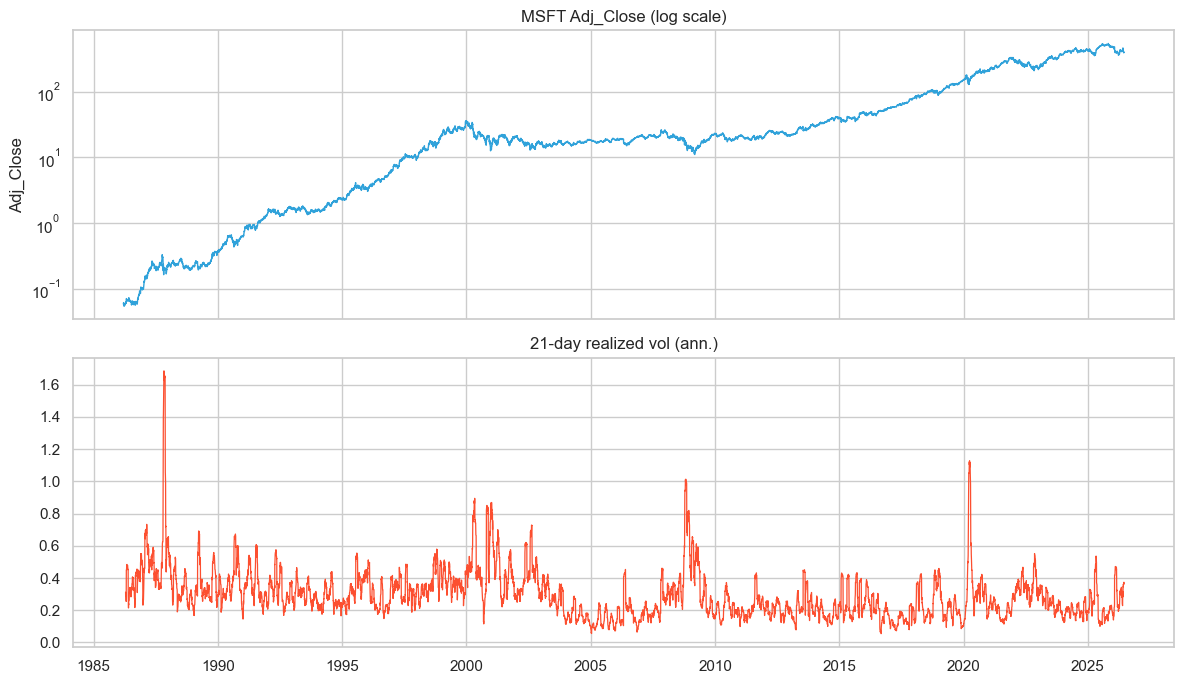

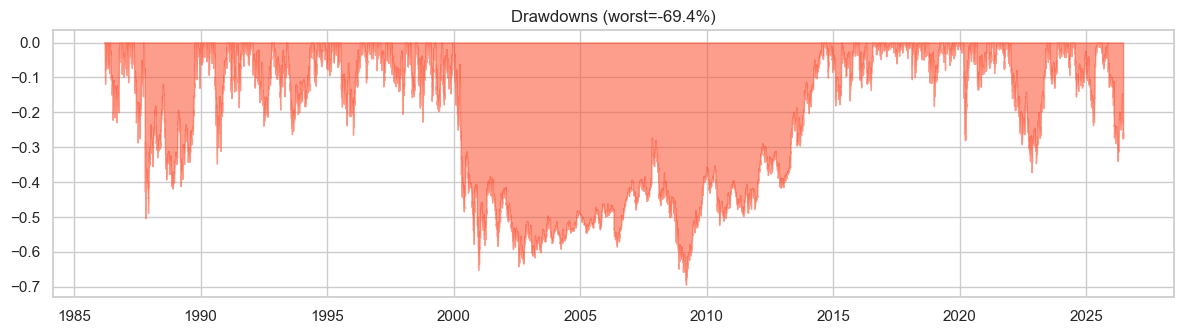

In [4]:
f, ax = plt.subplots(2, 1, figsize=(12, 7), sharex=True)
ax[0].plot(price["Date"], price["Adj_Close"], color="#30a2da", lw=1.0)
ax[0].set_yscale("log")
ax[0].set_title("MSFT Adj_Close (log scale)")
ax[0].set_ylabel("Adj_Close")
vol = price["ret"].rolling(21).std() * np.sqrt(252)
ax[1].plot(price["Date"], vol, color="#fc4f30", lw=0.9)
ax[1].set_title("21-day realized vol (ann.)")
plt.tight_layout()
plt.show()

dd = price.copy()
dd["cummax"] = dd["Adj_Close"].cummax()
dd["drawdown"] = dd["Adj_Close"] / dd["cummax"] - 1
f, ax = plt.subplots(figsize=(12, 3.5))
ax.fill_between(dd["Date"], dd["drawdown"], 0, color="#fc4f30", alpha=0.55)
ax.set_title(f"Drawdowns (worst={dd['drawdown'].min():.1%})")
plt.tight_layout()
plt.show()


**How to Interpret:** <br>
Log price makes early software-era growth and later cloud-era compounding comparable. Vol and drawdown panels mark crises (dot-com, GFC, COVID, etc.) without needing event labels.


# **4. Dividends and Splits:** <a id="Events"></a>


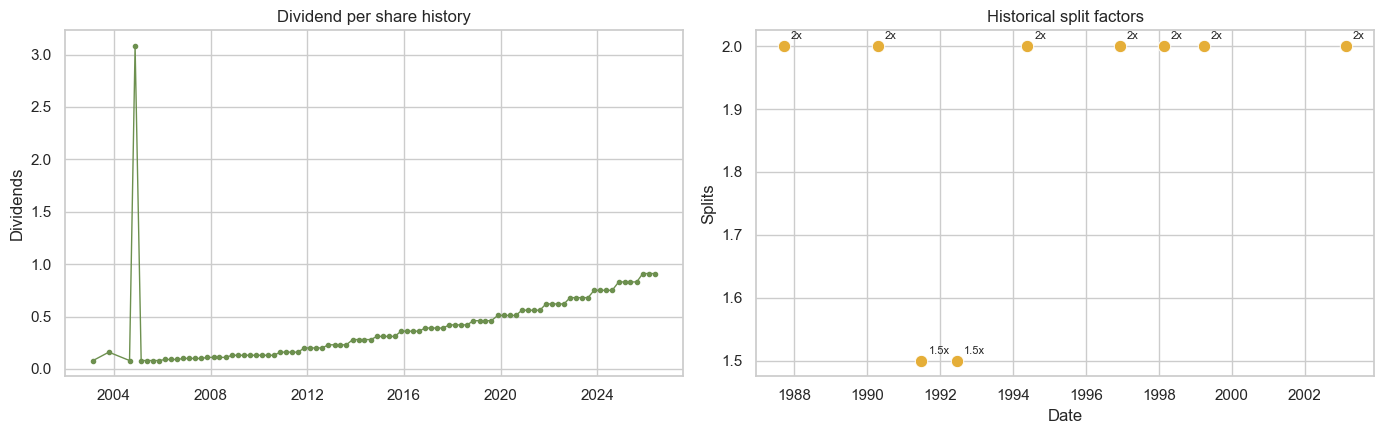

,Date,Splits
0,1987-09-21 04:00:00,2.0
1,1990-04-16 04:00:00,2.0
2,1991-06-27 04:00:00,1.5
3,1992-06-15 04:00:00,1.5
4,1994-05-23 04:00:00,2.0
5,1996-12-09 05:00:00,2.0
6,1998-02-23 05:00:00,2.0
7,1999-03-29 05:00:00,2.0
8,2003-02-18 05:00:00,2.0


In [5]:
f, ax = plt.subplots(1, 2, figsize=(14, 4.5))
if "Dividends" in div.columns:
    dcol = "Dividends"
else:
    # yfinance-style often uses Dividends as sole value col besides Date
    dcol = [c for c in div.columns if c != "Date"][0]
ax[0].plot(div["Date"], div[dcol], color="#6d904f", marker="o", ms=3, lw=1)
ax[0].set_title("Dividend per share history")
ax[0].set_ylabel(dcol)

sns.scatterplot(data=splits, x="Date", y="Splits", s=80, color="#e5ae38", ax=ax[1])
for _, r in splits.iterrows():
    ax[1].annotate(f"{r['Splits']:g}x", (r["Date"], r["Splits"]), textcoords="offset points", xytext=(5, 5), fontsize=8)
ax[1].set_title("Historical split factors")
plt.tight_layout()
plt.show()
display(splits.sort_values("Date"))


**How to Interpret:** <br>
Split markers explain stair-steps in unadjusted Close. Dividend series shows payout initiation/growth — overlay conceptually on Adj_Close rather than raw Close.


# **5. Recent Fundamentals:** <a id="Fundamentals"></a>


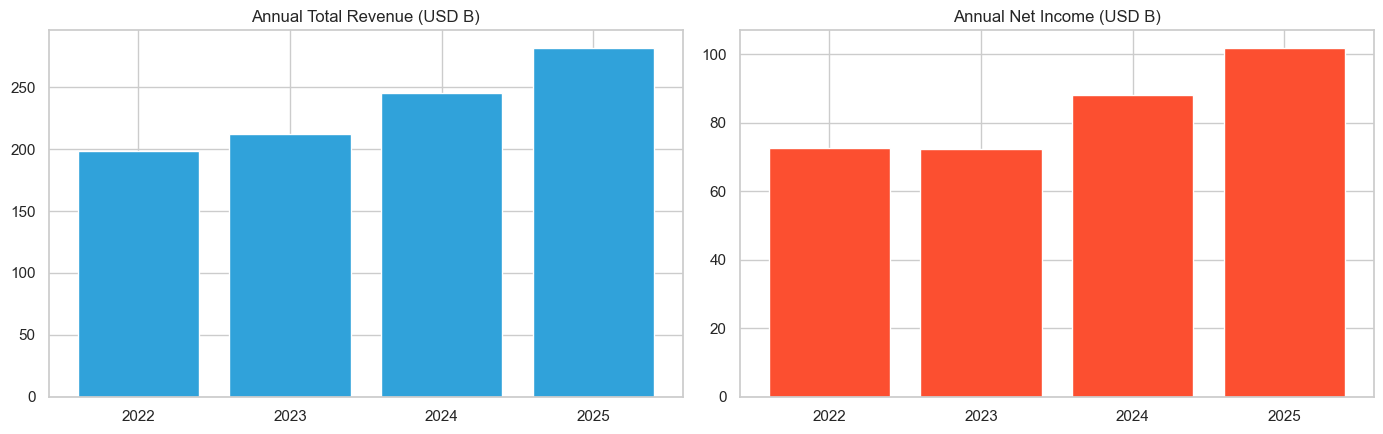

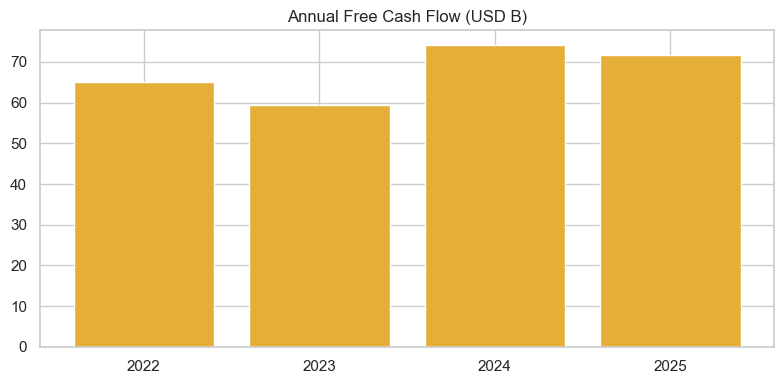

,Date,Total_Revenue_B,Net_Income_B,Diluted_EPS
3,2022-06-30,198.3,72.7,9.65
2,2023-06-30,211.9,72.4,9.68
1,2024-06-30,245.1,88.1,11.80
0,2025-06-30,281.7,101.8,13.64


Only 4 annual income rows — descriptive recent snapshot, not a 40-year fundamental panel.


In [6]:
assert {"Total_Revenue", "Net_Income"}.issubset(income.columns)
inc = income.sort_values("Date")
f, ax = plt.subplots(1, 2, figsize=(14, 4.5))
ax[0].bar(inc["Date"].dt.year.astype(str), inc["Total_Revenue"] / 1e9, color="#30a2da")
ax[0].set_title("Annual Total Revenue (USD B)")
ax[1].bar(inc["Date"].dt.year.astype(str), inc["Net_Income"] / 1e9, color="#fc4f30")
ax[1].set_title("Annual Net Income (USD B)")
plt.tight_layout()
plt.show()

if "Free_Cash_Flow" in cash.columns:
    c2 = cash.sort_values("Date")
    f, ax = plt.subplots(figsize=(8, 4))
    ax.bar(c2["Date"].dt.year.astype(str), c2["Free_Cash_Flow"] / 1e9, color="#e5ae38")
    ax.set_title("Annual Free Cash Flow (USD B)")
    plt.tight_layout()
    plt.show()
display(inc[["Date", "Total_Revenue", "Net_Income", "Diluted_EPS"]].assign(
    Total_Revenue_B=lambda d: (d["Total_Revenue"] / 1e9).round(1),
    Net_Income_B=lambda d: (d["Net_Income"] / 1e9).round(1),
)[["Date", "Total_Revenue_B", "Net_Income_B", "Diluted_EPS"]])
print("Only", len(inc), "annual income rows — descriptive recent snapshot, not a 40-year fundamental panel.")


**How to Interpret:** <br>
With ~4 annual statements, bars show recent trajectory only. Do not extrapolate 1986–era fundamentals from this file set.


# **6. Analyst Upgrades / Downgrades:** <a id="Analysts"></a>


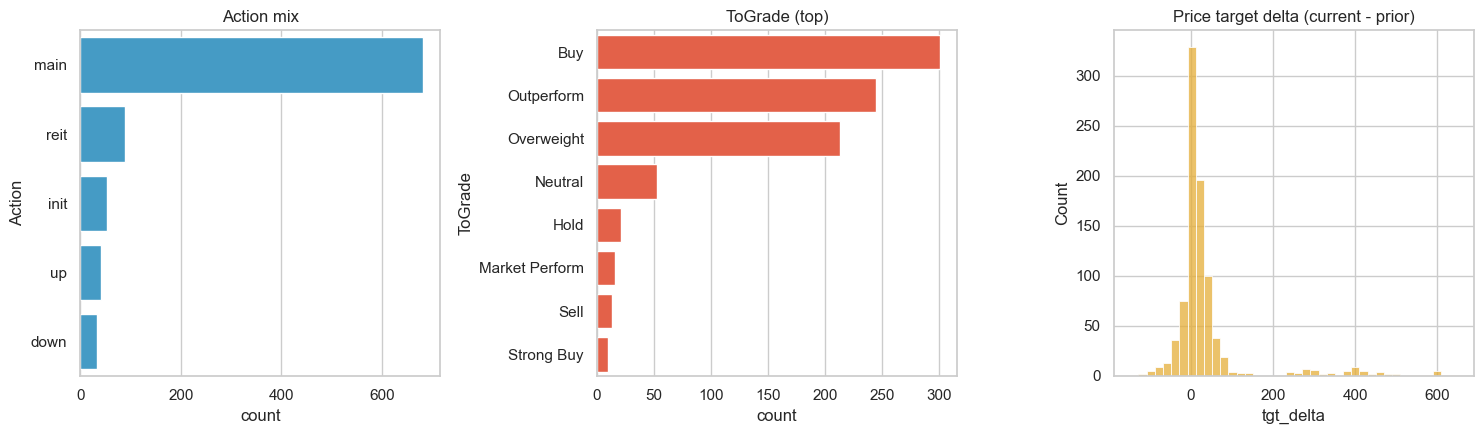

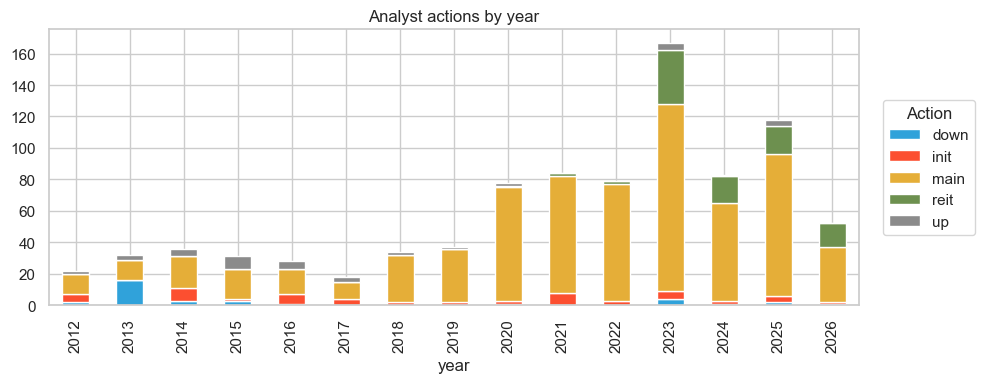

In [7]:
assert up["GradeDate"].notna().any()
f, ax = plt.subplots(1, 3, figsize=(15, 4.5))
sns.countplot(data=up, y="Action", order=up["Action"].value_counts().index, ax=ax[0], color="#30a2da")
ax[0].set_title("Action mix")
sns.countplot(data=up, y="ToGrade", order=up["ToGrade"].value_counts().head(8).index, ax=ax[1], color="#fc4f30")
ax[1].set_title("ToGrade (top)")
# Price target revision delta when both present
both = up.dropna(subset=["currentPriceTarget", "priorPriceTarget"]).copy()
both["tgt_delta"] = both["currentPriceTarget"] - both["priorPriceTarget"]
sns.histplot(both["tgt_delta"], bins=40, ax=ax[2], color="#e5ae38")
ax[2].set_title("Price target delta (current - prior)")
plt.tight_layout()
plt.show()

yearly_actions = up.dropna(subset=["GradeDate"]).assign(year=lambda d: d["GradeDate"].dt.year)
ct = pd.crosstab(yearly_actions["year"], yearly_actions["Action"])
f, ax = plt.subplots(figsize=(10, 4))
ct.plot(kind="bar", stacked=True, ax=ax, color=["#30a2da", "#fc4f30", "#e5ae38", "#6d904f", "#8b8b8b"][:ct.shape[1]])
ax.set_title("Analyst actions by year")
ax.legend(title="Action", bbox_to_anchor=(1.02, 0.5), loc="center left")
plt.tight_layout()
plt.show()


**How to Interpret:** <br>
Maintain/reiterate actions often dominate broker logs. Target deltas show revision direction; stacked yearly actions are coverage intensity, not a pure sentiment index.


# **7. What It Means — Working Synthesis:** <a id="Synthesis"></a>

**What the package is:** <br>
A long MSFT price history with thin recent fundamentals and analyst grade events.

**Working takeaways:** <br>
- Use `Adj_Close` for multi-decade paths; consult splits for unadjusted Close quirks.
- Fundamentals here are a short recent window.
- Skip broken `MSFT_recommendations.csv` timestamps.

**Open follow-ups:** <br>
- Event study around upgrade/downgrade dates vs subsequent returns.
- Dividend growth vs FCF coverage using the cashflow table.
